<a href="https://colab.research.google.com/github/rodrigodll46/Titanic/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução

 O naufrágio do RMS Titanic, em 1912, é um dos desastres mais famosos da história. Durante sua primeira viagem, o navio bateu em um iceberg no Oceano Atlântico Norte e afundou, causando a morte de muitos passageiros e tripulantes.

**Objetivo**
Este projeto tem como objetivo identificar e analisar os principais fatores que influenciaram a sobrevivência dos passageiros do Titanic.
Para isso, será feita uma Análise Exploratória de Dados (EDA) utilizando o conjunto de dados do Titanic. A ideia é entender melhor o perfil dos passageiros e verificar quais características podem ter impactado suas chances de sobreviver.


# Importação e carregamento dos dados

In [1]:
# Neste projeto, são utilizadas as bibliotecas: Pandas trabalhar com o dataset, NumPy para cálculos numéricos e Matplotlib junto com o Seaborn para criar gráficos durante a análise

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
#  O conjunto de dados é obtido por meio de um link fornecido pelo curso, sendo enviado para o GitHub, organizado em uma pasta e acessado pelo seu caminho

url = "https://raw.githubusercontent.com/rodrigodll46/Titanic/main/conjunto%20de%20dados/titanic_dataset.csv"
df_dataset = pd.read_csv(url)
df = df_dataset.copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Dataframe somente com as colunas mais relevantes para a análise

df_main = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
df_main.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# Limpeza de dados

In [6]:
# Removendo duplicadas

print(f"Antes da remoção de duplicadas: {df_main.shape[0]}")
df_clean = df_main.drop_duplicates().copy()
print(f"Depois da remoção de duplicadas: {df_clean.shape[0]}")

Antes da remoção de duplicadas: 891
Depois da remoção de duplicadas: 780


In [7]:
# Verificando valores nulos

print('Valores nulos antes do tratamento:')
print(df_clean.isnull().sum())


Valores nulos antes do tratamento:
Survived      0
Pclass        0
Sex           0
Age         104
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


In [8]:
# Tratar Age: mediana
median_age = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(median_age)
print("Valores nulos em 'Age' preenchidos com a mediana:", median_age)

Valores nulos em 'Age' preenchidos com a mediana: 28.0


In [9]:
# Tratar Embarked: moda
mode_embarked = df_clean['Embarked'].mode()[0]
df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)
print("Valores nulos em 'Embarked' preenchidos com a moda:", mode_embarked)

Valores nulos em 'Embarked' preenchidos com a moda: S


In [10]:
# Tratando os tipos de dados

df_clean['Survived'] = df_clean['Survived'].astype('category')
df_clean['Pclass'] = df_clean['Pclass'].astype('category')
df_clean['Sex'] = df_clean['Sex'].astype('category')
df_clean['Embarked'] = df_clean['Embarked'].astype('category')
print("DataFrame com tipagem atualizada:")
df_clean.dtypes

DataFrame com tipagem atualizada:


,0
Survived,category
Pclass,category
Sex,category
Age,float64
SibSp,int64
Parch,int64
Fare,float64
Embarked,category


In [11]:
# Novo dataframe com atualizações e tratamento

df_titanic = df_clean.copy()
df_titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


# Análise exploratória

## Sobrevivência Geral


 A variável Survived indica quem sobreviveu (1) e quem não sobreviveu (0).



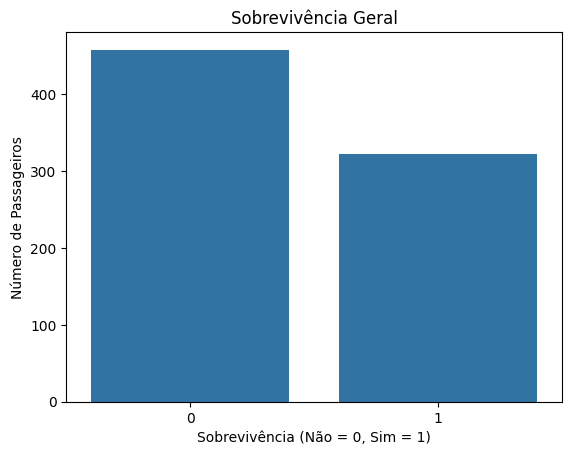

In [12]:
sns.countplot(x='Survived', data=df_titanic)
plt.title('Sobrevivência Geral')
plt.xlabel('Sobrevivência (Não = 0, Sim = 1)')
plt.ylabel('Número de Passageiros')
plt.show()

A análise mostra que a maioria dos passageiros não sobreviveu ao naufrágio.


## Sobrevivência por Gênero

 O gênero pode ter sido um fator importante na sobrevivência, já que há relatos de que mulheres e crianças tiveram prioridade nos botes.



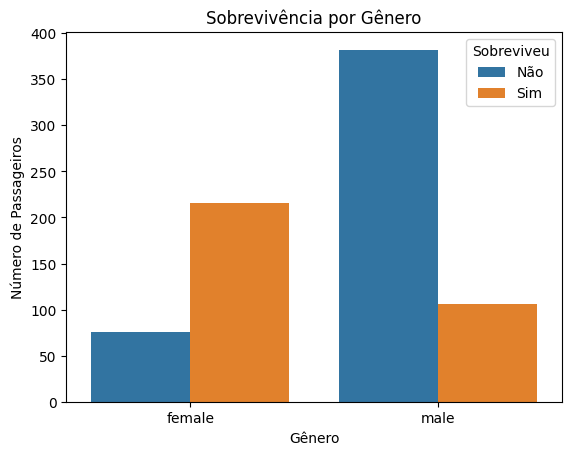

In [13]:
sns.countplot(x='Sex', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

Os dados mostram uma grande diferença entre homens e mulheres: as mulheres tiveram uma taxa de sobrevivência muito maior.
Isso indica que o gênero foi um dos fatores mais relevantes, provavelmente por causa da prioridade no resgate.

## Sobrevivência por Classe

 Os passageiros estavam divididos em três classes (Pclass), que também indicam nível socioeconômico.



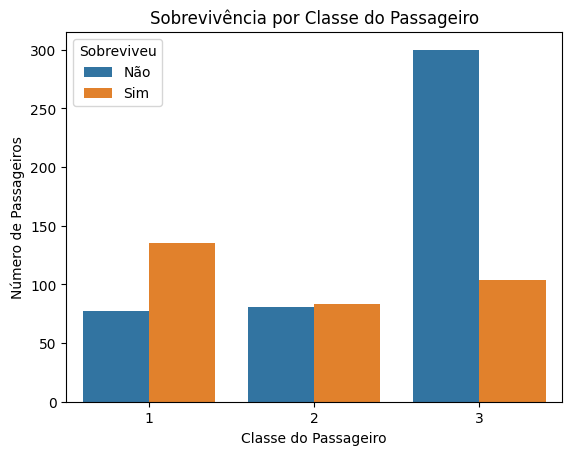

In [14]:
sns.countplot(x='Pclass', hue='Survived', data=df_titanic)
plt.title('Sobrevivência por Classe do Passageiro')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])
plt.show()

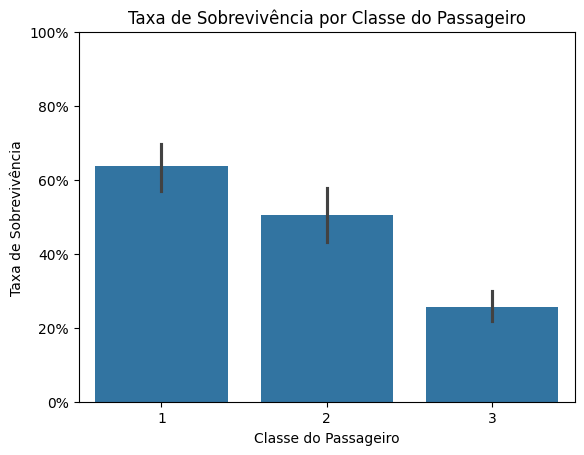

In [15]:
from matplotlib.ticker import PercentFormatter
sns.barplot(x='Pclass', y='Survived', data=df_titanic, order=[1,2,3])
plt.title('Taxa de Sobrevivência por Classe do Passageiro')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

A análise mostra que passageiros da primeira classe tiveram maior taxa de sobrevivência, enquanto os da terceira classe tiveram as menores.
Isso pode estar relacionado à localização no navio, acesso aos botes e prioridade no resgate. Passageiros de classes mais altas provavelmente tiveram mais facilidade para escapar.
Assim, a classe também foi um fator importante.

## Sobrevivência por Idade

 Em situações de emergência, crianças costumam ter prioridade, o que pode influenciar a sobrevivência.



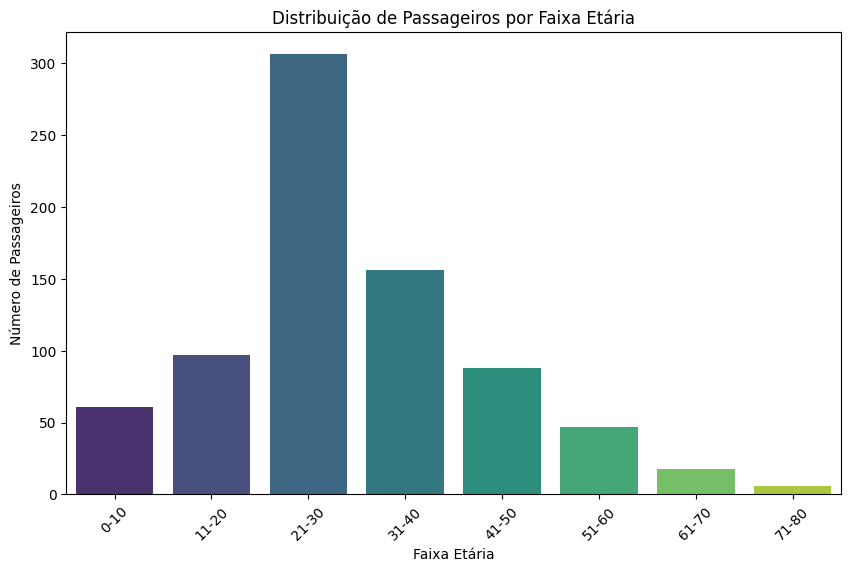

In [16]:
# Feature engineering: AgeGroup
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80']

df_temp = df_titanic.copy()
df_temp['AgeGroup'] = pd.cut(df_temp['Age'], bins=age_bins, labels=age_labels, right=False)

plt.figure(figsize=(10, 6))
sns.countplot(x='AgeGroup', data=df_temp, palette='viridis', hue='AgeGroup', legend=False)
plt.title('Distribuição de Passageiros por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Número de Passageiros')
plt.xticks(rotation=45)
plt.show()

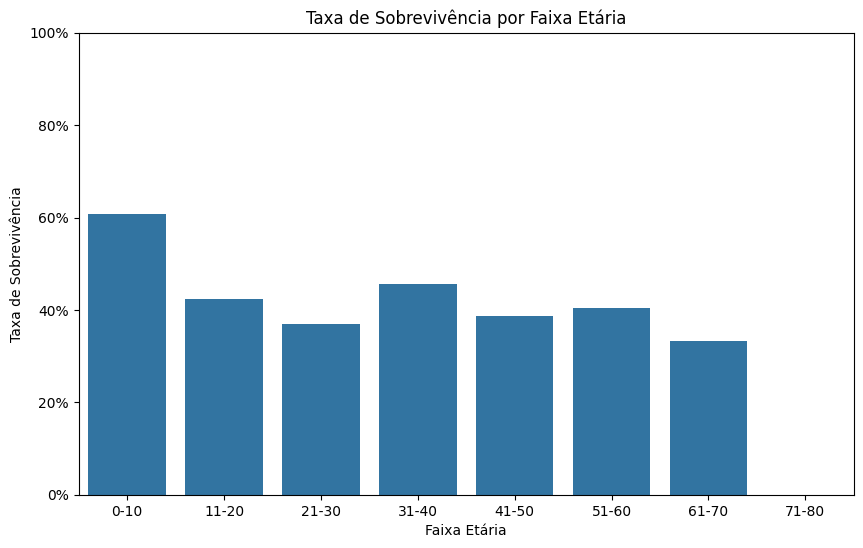

In [17]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80']

df_temp = df_titanic.copy()
df_temp['AgeGroup'] = pd.cut(df_temp['Age'], bins=age_bins, labels=age_labels, right=False)

survival_rate_by_age_group = df_temp.groupby('AgeGroup', observed=False)['Survived'].apply(lambda x: x.astype(int).mean()).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Survived', data=survival_rate_by_age_group)
plt.title('Taxa de Sobrevivência por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0, 1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.show()

Os dados indicam que crianças tiveram uma taxa de sobrevivência maior do que adultos.
Mesmo assim, pessoas de todas as idades foram afetadas, mostrando que a idade não foi o único fator importante.

## Sobrevivência por Gênero e Classe

 Essa análise mostra como gênero e classe juntos influenciam a sobrevivência.



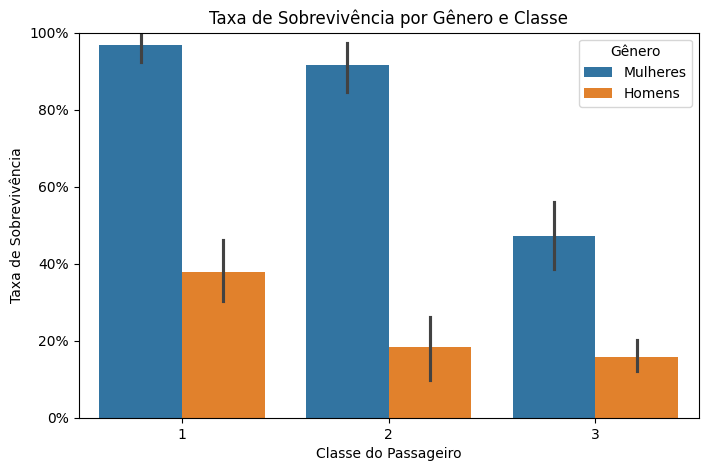

In [18]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df_titanic)
plt.title('Taxa de Sobrevivência por Gênero e Classe')
plt.xlabel('Classe do Passageiro')
plt.ylabel('Taxa de Sobrevivência')
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
handles, labels = ax.get_legend_handles_labels()
labels = ['Homens' if l=='male' else 'Mulheres' for l in labels]
ax.legend(handles, labels, title='Gênero')
plt.show()

Os dados indicam que as mulheres tiveram maior taxa de sobrevivência em todas as classes.
Além disso, passageiros da primeira classe tiveram mais chances de sobreviver do que os das classes mais baixas.
Entre os homens, a sobrevivência foi bem menor, principalmente na terceira classe.

## Sobrevivência por Idade e Gênero

Aqui analisamos idade, gênero e sobrevivência ao mesmo tempo.



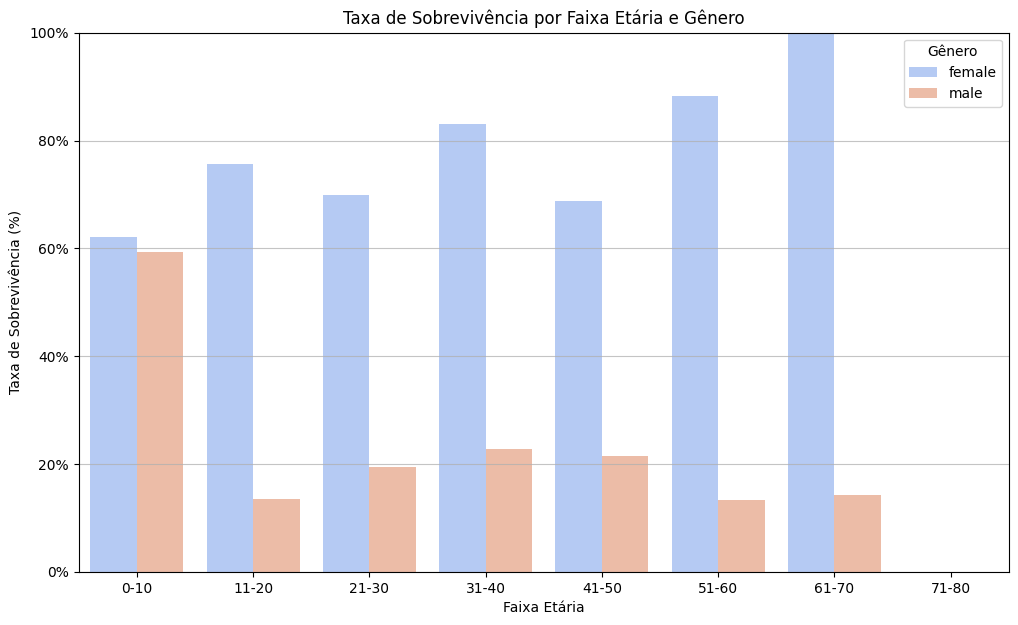

In [19]:
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80]
age_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80']

df_plot = df_titanic.copy()
df_plot['AgeGroup'] = pd.cut(df_plot['Age'], bins=age_bins, labels=age_labels, right=False)

survival_rate_by_age_sex = df_plot.groupby(['AgeGroup', 'Sex'], observed=False)['Survived'].apply(lambda x: x.astype(int).mean()).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='AgeGroup', y='Survived', hue='Sex', data=survival_rate_by_age_sex, palette='coolwarm')
plt.title('Taxa de Sobrevivência por Faixa Etária e Gênero')
plt.xlabel('Faixa Etária')
plt.ylabel('Taxa de Sobrevivência (%)')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.75)
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.legend(title='Gênero')
plt.show()

Os resultados mostram que crianças e mulheres tiveram maiores chances de sobreviver.
Isso reforça a ideia de que esses grupos tiveram prioridade durante o resgate.

# Principais Insights da Análise


*   **Gênero** foi o fator mais importante

*   Passageiros da **1ª classe** tiveram vantagem


*   **Crianças** tiveram maior sobrevivência



**Conclusão**

 Os principais fatores de sobrevivência no desastre do Titanic foram gênero, classe e idade. Mulheres e passageiros da primeira classe tiveram mais chances de sobreviver, enquanto homens da terceira classe tiveram as menores.

Esses resultados mostram como a análise de dados pode ajudar a entender melhor eventos históricos e identificar padrões importantes, que podem contribuir para melhorar decisões e prevenir situações semelhantes no futuro.